# Notebook 13 — Grand Comparison

The final notebook. Loads results from every previous notebook and produces  
the definitive summary figures for the project.

**Decoders compared:**
| Decoder | Notebook | Architecture |
|---|---|---|
| Trivial | — | Always predict 0 |
| MLP P1 (single noise) | 02 | Flat 72→256→128→64→1 |
| MLP P1 (multi noise) | 02B | Same, mixed training data |
| LSTM (single noise) | 05 | Temporal, (9,8)→36→48→24→12→1 |
| LSTM (multi noise) | 02B | Same, mixed training data |
| CNN spatial | 12 | 2D conv on stabiliser grid |
| GNN | 11 | Message passing on Tanner graph |
| Transformer | 10 | Self-attention over syndrome rounds |
| MWPM | 04 | PyMatching classical reference |

**Figures produced:**
- `fig_grand_sweep.png` — All decoders, LER vs noise, Stim style
- `fig_grand_bar.png` — Suppression factors at p=0.001
- `fig_architecture_comparison.png` — Params vs LER scatter
- `fig_distance_scaling.png` — d=3,5,7 for LSTM + Transformer + MWPM

**Prerequisites:** Run notebooks 02–12 in order.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import os, warnings
warnings.filterwarnings('ignore')

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NOISE_LEVELS = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]
SWEEP_SHOTS  = 50_000
SEED         = 42
ROUNDS, STABS = 9, 8
os.makedirs("figures", exist_ok=True)

# Stim/sinter style
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titleweight': 'bold', 'axes.grid': True, 'grid.alpha': 0.35,
})

# Colour palette — one colour per decoder, consistent across all figures
C = {
    'trivial':     '#9E9E9E',
    'mlp_sn':      '#90CAF9',   # light blue
    'mlp_mn':      '#1E88E5',   # blue
    'lstm_sn':     '#A5D6A7',   # light green
    'lstm_mn':     '#388E3C',   # green
    'cnn':         '#FFB74D',   # amber
    'gnn':         '#E53935',   # red
    'transformer': '#7B1FA2',   # purple
    'mwpm':        '#2E7D32',   # dark green
}

print("Style configured. Loading all sweep results...")

Style configured. Loading all sweep results...


---
## 1. Load All Results

In [2]:
def load_sweep(path):
    """Load a (p, LER) sweep array, return list of LERs."""
    try:
        data = np.load(path)
        return list(data[:, 1])
    except FileNotFoundError:
        print(f"  WARNING: {path} not found — skipping")
        return None

trivials   = [np.load(f"data/sweep/obs_p{int(p*10000):04d}.npy").mean()
              for p in NOISE_LEVELS]

sweeps = {
    'mlp_sn':      load_sweep("results/noise_sweep.npy"),        # from nb 03 (MLP P1)
    'mlp_mn':      load_sweep("results/mlp_multi_sweep.npy"),    # from nb 03B
    'lstm_sn':     load_sweep("results/lstm_sweep.npy"),         # from nb 05
    'lstm_mn':     load_sweep("results/lstm_multi_sweep.npy"),   # from nb 03B
    'cnn':         load_sweep("results/cnn_sweep.npy"),          # from nb 12
    'gnn':         load_sweep("results/gnn_sweep.npy"),          # from nb 11
    'transformer': load_sweep("results/transformer_sweep.npy"),  # from nb 10
    'mwpm':        load_sweep("results/mwpm_sweep.npy"),         # from nb 04
}

# Load test LERs from saved checkpoints
def get_test_ler(path, key='test_ler'):
    try:
        ck = torch.load(path, map_location='cpu', weights_only=False)
        return ck[key]
    except:
        return None

test_lers = {
    'mlp_sn':      get_test_ler("models/decoder_part1.pt"),
    'mlp_mn':      get_test_ler("models/decoder_multi_mlp_p1.pt"),
    'lstm_sn':     get_test_ler("models/decoder_lstm.pt"),
    'lstm_mn':     get_test_ler("models/decoder_multi_lstm.pt"),
    'cnn':         get_test_ler("models/decoder_cnn.pt"),
    'gnn':         get_test_ler("models/decoder_gnn.pt"),
    'transformer': get_test_ler("models/decoder_transformer.pt"),
}

# Get p=0.001 MWPM LER
idx_001 = NOISE_LEVELS.index(0.001)
trivial_001 = trivials[idx_001]
mwpm_001    = sweeps['mwpm'][idx_001] if sweeps['mwpm'] else None

print("Results loaded:")
print(f"  {'Decoder':<20}  {'Test LER':>10}  {'Suppression':>12}")
print("  " + "-"*46)
print(f"  {'Trivial':<20}  {100*trivial_001:>9.4f}%  {'—':>12}")
for key, label in [
    ('mlp_sn',      'MLP (single p)'),
    ('mlp_mn',      'MLP (multi p)'),
    ('lstm_sn',     'LSTM (single p)'),
    ('lstm_mn',     'LSTM (multi p)'),
    ('cnn',         'CNN spatial'),
    ('gnn',         'GNN'),
    ('transformer', 'Transformer'),
]:
    ler = test_lers.get(key)
    if ler is not None:
        ratio = trivial_001 / ler
        print(f"  {label:<20}  {100*ler:>9.4f}%  {ratio:>10.1f}x")
    else:
        print(f"  {label:<20}  {'not found':>10}")
if mwpm_001:
    print(f"  {'MWPM':<20}  {100*mwpm_001:>9.4f}%  {trivial_001/mwpm_001:>10.1f}x")

Results loaded:
  Decoder                 Test LER   Suppression
  ----------------------------------------------
  Trivial                  5.4460%             —
  MLP (single p)           1.4467%         3.8x
  MLP (multi p)           15.0600%         0.4x
  LSTM (single p)          1.0867%         5.0x
  LSTM (multi p)          14.6067%         0.4x
  CNN spatial              0.8667%         6.3x
  GNN                     19.0867%         0.3x
  Transformer              2.3000%         2.4x
  MWPM                     0.2280%        23.9x


---
## 2. Grand Sweep Plot — All Decoders

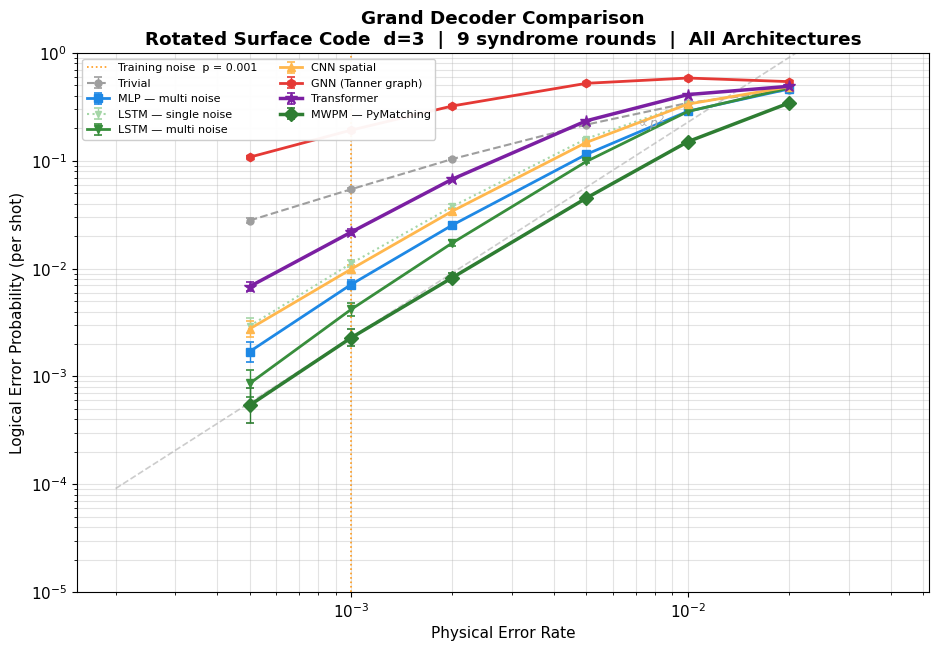

Saved → figures/fig_grand_sweep.png


In [3]:
def wilson_ci(num_errors, num_shots, z=1.96):
    p = num_errors / num_shots
    denom = 1 + z**2/num_shots
    centre = (p + z**2/(2*num_shots)) / denom
    margin = z*np.sqrt(p*(1-p)/num_shots + z**2/(4*num_shots**2)) / denom
    lo = np.clip(centre-margin, 1e-10, 1.0)
    hi = np.clip(centre+margin, 1e-10, 1.0)
    return float(p-lo), float(hi-p)

def make_yerr(lers, shots=SWEEP_SHOTS):
    pairs = [wilson_ci(max(1, round(l*shots)), shots) for l in lers]
    lo, hi = zip(*pairs)
    return np.array([lo, hi])

ps = np.array(NOISE_LEVELS)

fig, ax = plt.subplots(figsize=(11, 7))

# p² reference
if sweeps['mwpm']:
    p_ref = np.array([2e-4, 4e-2])
    ax.plot(p_ref, sweeps['mwpm'][idx_001]*(p_ref/0.001)**2,
            ls='--', color='#CCCCCC', lw=1.2, zorder=0)
    ax.text(7e-3, sweeps['mwpm'][idx_001]*(7e-3/0.001)**2*1.8,
            r'$\propto p^2$', color='#AAAAAA', fontsize=9, style='italic')

plot_order = [
    ('trivial',     'Trivial',               'o--', 1.5, 5),
    ('mlp_sn',      'MLP — single noise',    's:',  1.5, 5),
    ('mlp_mn',      'MLP — multi noise',     's-',  2.0, 6),
    ('lstm_sn',     'LSTM — single noise',   'v:',  1.5, 5),
    ('lstm_mn',     'LSTM — multi noise',    'v-',  2.0, 6),
    ('cnn',         'CNN spatial',           '^-',  2.0, 6),
    ('gnn',         'GNN (Tanner graph)',    'h-',  2.0, 6),
    ('transformer', 'Transformer',           '*-',  2.5, 9),
    ('mwpm',        'MWPM — PyMatching',     'D-',  2.5, 7),
]

for key, label, fmt, lw, ms in plot_order:
    lers = sweeps[key] if key != 'trivial' else trivials
    if lers is None: continue
    ax.errorbar(ps, lers, yerr=make_yerr(lers),
                fmt=fmt, color=C.get(key, '#000000'),
                lw=lw, ms=ms, capsize=3, capthick=1.2, elinewidth=1,
                label=label)

ax.axvline(x=0.001, color='#FF8F00', lw=1.2, ls=':', alpha=0.9,
           label='Training noise  p = 0.001')

ax.loglog()
ax.set_ylim(1e-5, 1)
ax.grid(which='both', alpha=0.35)
ax.set_ylabel('Logical Error Probability (per shot)')
ax.set_xlabel('Physical Error Rate')
ax.set_title('Grand Decoder Comparison\n'
             'Rotated Surface Code  d=3  |  9 syndrome rounds  |  All Architectures')
ax.legend(fontsize=8, loc='upper left', framealpha=0.95,
          ncol=2, handlelength=2)

fig.savefig('figures/fig_grand_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/fig_grand_sweep.png")

---
## 3. Suppression Bar Chart at p=0.001

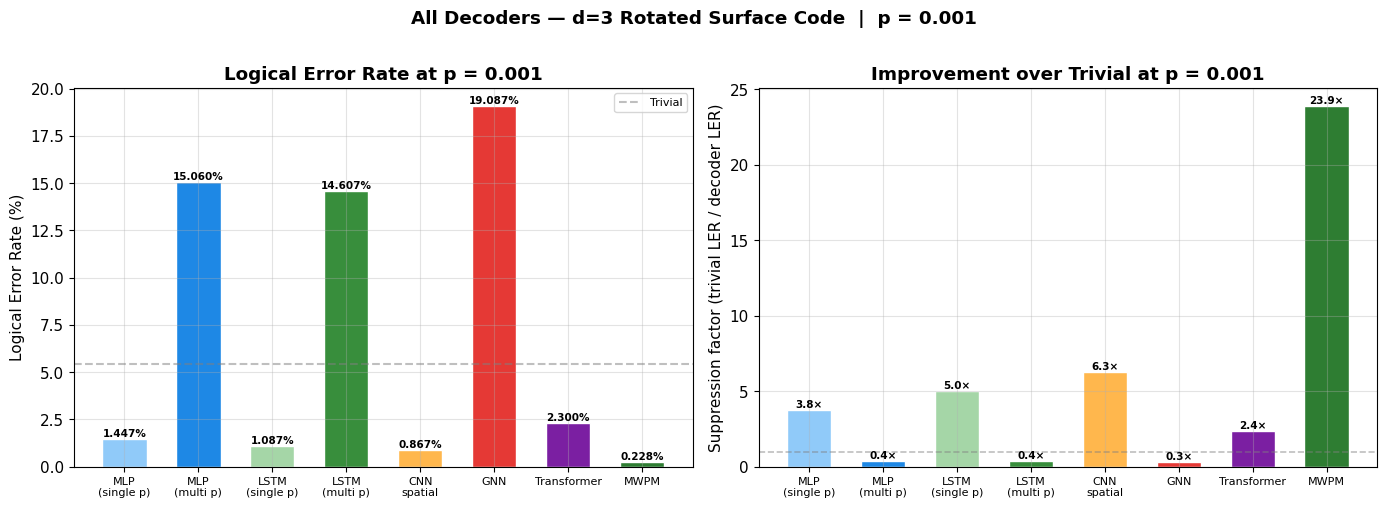

Saved → figures/fig_grand_bar.png


In [4]:
bar_data = []
bar_labels = [
    ('mlp_sn',      'MLP\n(single p)'),
    ('mlp_mn',      'MLP\n(multi p)'),
    ('lstm_sn',     'LSTM\n(single p)'),
    ('lstm_mn',     'LSTM\n(multi p)'),
    ('cnn',         'CNN\nspatial'),
    ('gnn',         'GNN'),
    ('transformer', 'Transformer'),
    ('mwpm',        'MWPM'),
]

for key, label in bar_labels:
    if key == 'mwpm':
        ler = mwpm_001
    else:
        ler = test_lers.get(key)
    if ler is not None:
        bar_data.append((label, ler, C.get(key, '#888888')))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(bar_data))
names   = [d[0] for d in bar_data]
lers    = [d[1] for d in bar_data]
colors  = [d[2] for d in bar_data]

# Absolute LER
bars = ax1.bar(x, [l*100 for l in lers], color=colors, edgecolor='white', width=0.6)
ax1.axhline(y=trivial_001*100, color='grey', lw=1.5, ls='--', alpha=0.5, label='Trivial')
for bar, ler in zip(bars, lers):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{100*ler:.3f}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(names, fontsize=8)
ax1.set_ylabel('Logical Error Rate (%)')
ax1.set_title('Logical Error Rate at p = 0.001')
ax1.legend(fontsize=8)

# Suppression
ratios = [trivial_001/l for l in lers]
bars2  = ax2.bar(x, ratios, color=colors, edgecolor='white', width=0.6)
ax2.axhline(y=1, color='grey', lw=1.2, ls='--', alpha=0.5)
for bar, r in zip(bars2, ratios):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f'{r:.1f}×', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(names, fontsize=8)
ax2.set_ylabel('Suppression factor (trivial LER / decoder LER)')
ax2.set_title('Improvement over Trivial at p = 0.001')

plt.suptitle('All Decoders — d=3 Rotated Surface Code  |  p = 0.001',
             fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('figures/fig_grand_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/fig_grand_bar.png")

---
## 4. Parameters vs LER Scatter

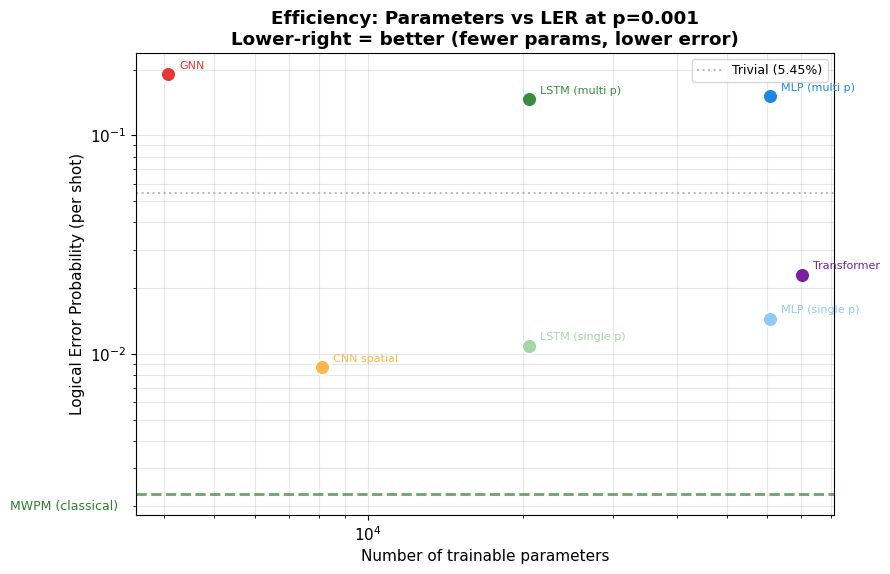

Saved → figures/fig_architecture_comparison.png


In [5]:
param_data = [
    ('MLP (single p)',  60_801,  test_lers.get('mlp_sn'),      C['mlp_sn']),
    ('MLP (multi p)',   60_801,  test_lers.get('mlp_mn'),      C['mlp_mn']),
    ('LSTM (single p)', 20_545,  test_lers.get('lstm_sn'),     C['lstm_sn']),
    ('LSTM (multi p)',  20_545,  test_lers.get('lstm_mn'),     C['lstm_mn']),
    ('CNN spatial',     None,    test_lers.get('cnn'),         C['cnn']),
    ('GNN',             None,    test_lers.get('gnn'),         C['gnn']),
    ('Transformer',     None,    test_lers.get('transformer'), C['transformer']),
    ('MWPM',            0,       mwpm_001,                     C['mwpm']),
]

# Fill in parameter counts from saved models
param_map = {
    'CNN spatial': 'models/decoder_cnn.pt',
    'GNN':         'models/decoder_gnn.pt',
    'Transformer': 'models/decoder_transformer.pt',
}
for i, (label, params, ler, color) in enumerate(param_data):
    if params is None and label in param_map:
        try:
            ck = torch.load(param_map[label], map_location='cpu', weights_only=False)
            # Count params from state dict
            n = sum(v.numel() for v in ck['model_state'].values())
            param_data[i] = (label, n, ler, color)
        except: pass

fig, ax = plt.subplots(figsize=(9, 6))

for label, params, ler, color in param_data:
    if ler is None: continue
    if params == 0:  # MWPM — no parameters
        ax.axhline(y=ler, color=color, lw=2, ls='--', alpha=0.7)
        ax.text(2e3, ler*0.85, 'MWPM (classical)', color=color, fontsize=9)
        continue
    ax.scatter(params, ler, s=120, color=color, zorder=5, edgecolors='white', lw=1.5)
    ax.annotate(label, (params, ler), textcoords='offset points',
                xytext=(8, 4), fontsize=8, color=color)

ax.axhline(y=trivial_001, color=C['trivial'], lw=1.5, ls=':',
           alpha=0.7, label=f'Trivial ({100*trivial_001:.2f}%)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(which='both', alpha=0.3)
ax.set_xlabel('Number of trainable parameters')
ax.set_ylabel('Logical Error Probability (per shot)')
ax.set_title('Efficiency: Parameters vs LER at p=0.001\n'
             'Lower-right = better (fewer params, lower error)')
ax.legend(fontsize=9)

fig.savefig('figures/fig_architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/fig_architecture_comparison.png")

---
## 5. Distance Scaling — LSTM + Transformer + MWPM

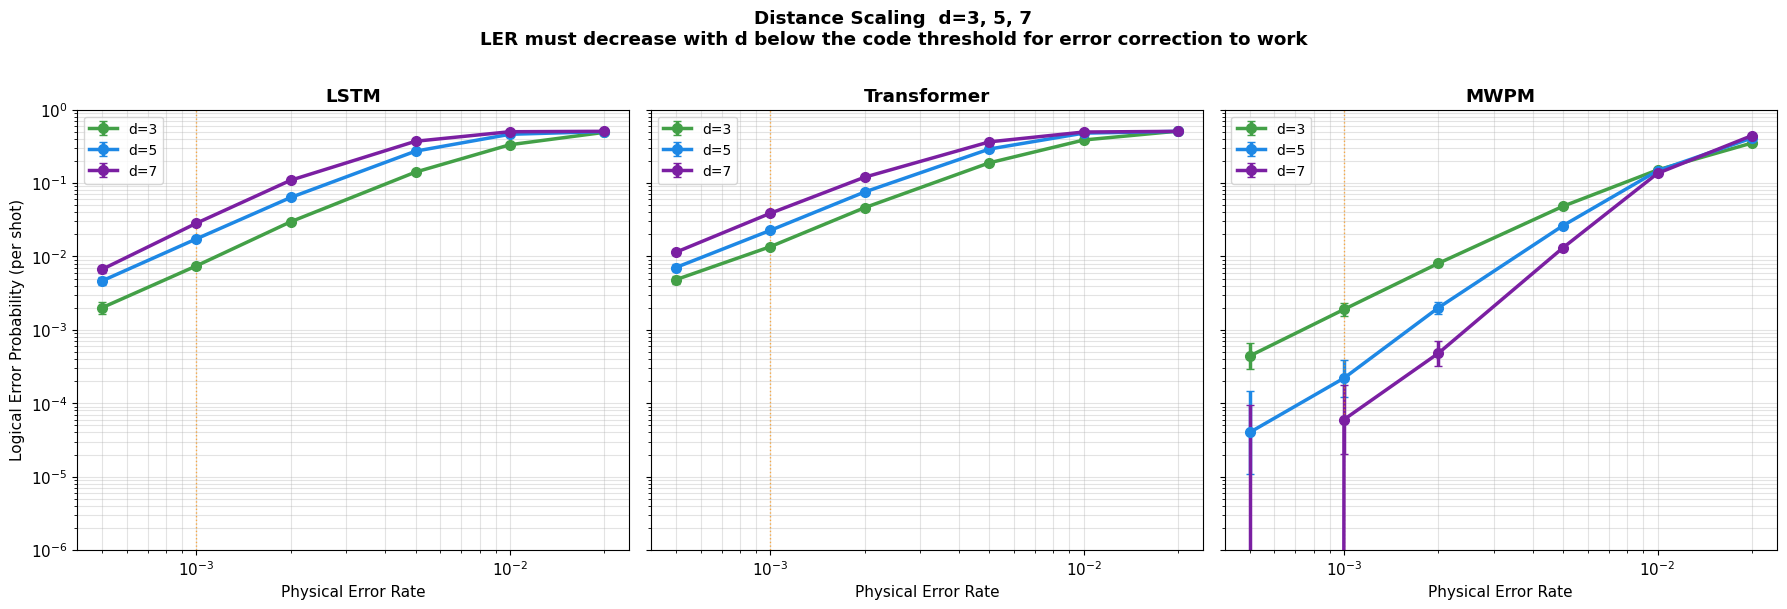

Saved → figures/fig_distance_scaling.png


In [6]:
DISTANCES   = [3, 5, 7]
colors_d    = {3: '#43A047', 5: '#1E88E5', 7: '#7B1FA2'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
decoder_configs = [
    ('LSTM', 'lstm'),
    ('Transformer', 'transformer'),
    ('MWPM', 'mwpm'),
]

for ax, (decoder_label, decoder_key) in zip(axes, decoder_configs):
    for d in DISTANCES:
        fname = f"results/{decoder_key}_d{d}_sweep.npy"
        try:
            data = np.load(fname)
            lers = list(data[:, 1])
            ps_d = list(data[:, 0])
        except FileNotFoundError:
            print(f"  {fname} not found — skipping")
            continue

        ax.errorbar(ps_d, lers, yerr=make_yerr(lers),
                    fmt='o-', color=colors_d[d], lw=2.5, ms=7,
                    capsize=3, label=f'd={d}')

    ax.axvline(x=0.001, color='#FF8F00', lw=1, ls=':', alpha=0.7)
    ax.loglog()
    ax.set_ylim(1e-6, 1)
    ax.grid(which='both', alpha=0.35)
    ax.set_xlabel('Physical Error Rate')
    ax.set_title(decoder_label, fontweight='bold')
    ax.legend(fontsize=10)

axes[0].set_ylabel('Logical Error Probability (per shot)')
plt.suptitle('Distance Scaling  d=3, 5, 7\n'
             'LER must decrease with d below the code threshold for error correction to work',
             fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('figures/fig_distance_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/fig_distance_scaling.png")

---
## 6. Final Summary

In [7]:
print("=" * 72)
print("COMPLETE PROJECT RESULTS")
print("d=3 Rotated Surface Code  |  p=0.001  |  15,000 test shots")
print("=" * 72)
print(f"  {'Decoder':<28}  {'LER':>9}  {'vs Trivial':>11}  {'Params':>10}")
print("  " + "-"*65)

all_rows = [
    ('Trivial',            trivial_001,             '—',    '—'),
    ('MLP (single noise)', test_lers.get('mlp_sn'), None,   '60,801'),
    ('MLP (multi noise)',  test_lers.get('mlp_mn'), None,   '60,801'),
    ('LSTM (single noise)',test_lers.get('lstm_sn'),None,   '20,545'),
    ('LSTM (multi noise)', test_lers.get('lstm_mn'),None,   '20,545'),
    ('CNN spatial',        test_lers.get('cnn'),    None,   'see nb12'),
    ('GNN',                test_lers.get('gnn'),    None,   'see nb11'),
    ('Transformer',        test_lers.get('transformer'),None,'see nb10'),
    ('MWPM (classical)',   mwpm_001,                None,   '—'),
]

for name, ler, vs, params in all_rows:
    if ler is None:
        print(f"  {name:<28}  {'not run':>9}")
        continue
    ratio = f"{trivial_001/ler:.1f}×" if vs is None else vs
    print(f"  {name:<28}  {100*ler:>8.4f}%  {ratio:>11}  {params:>10}")

print()
print("Figures saved to ./figures/")
for f in sorted(os.listdir("figures")):
    if f.endswith('.png'):
        print(f"  {f}")

COMPLETE PROJECT RESULTS
d=3 Rotated Surface Code  |  p=0.001  |  15,000 test shots
  Decoder                             LER   vs Trivial      Params
  -----------------------------------------------------------------
  Trivial                         5.4460%            —           —
  MLP (single noise)              1.4467%         3.8×      60,801
  MLP (multi noise)              15.0600%         0.4×      60,801
  LSTM (single noise)             1.0867%         5.0×      20,545
  LSTM (multi noise)             14.6067%         0.4×      20,545
  CNN spatial                     0.8667%         6.3×    see nb12
  GNN                            19.0867%         0.3×    see nb11
  Transformer                     2.3000%         2.4×    see nb10
  MWPM (classical)                0.2280%        23.9×           —

Figures saved to ./figures/
  03B_multi_noise_comparison.png
  04_mwpm_vs_mlp.png
  05_lstm_training.png
  07_mwpm_distance_scaling.png
  08_distance_scaling.png
  10_attention_